# Normalizing flows

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

import galah as galah
import helper as dl
import normalizing_flow as flow

torchdiffeq not found - no support for continuous flows. Install *torchdiffeq* if support is desired!
Meander not installed... contours can not be calculated.
Healpy not installed... spherical contours can not be calculated.
package *astropy* not found -> if you want to use plotting functionality for adaptive grids, install *astropy*!
package *mhealpy* not found -> if you want to use plotting functionality for adaptive grids, install *mhealpy*!
Cannot use healpy functionality. Install healpy, if you need to do entropy scanning!


In [32]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(galah)
importlib.reload(dl)
importlib.reload(flow);

### Loading data

In [ ]:
DATA_PATH = "../datasets/galah"

# Load the data
spectra, labels, label_names, units, spectra_length, n_labels, n_samples = galah.load_galah_data(DATA_PATH)

### Hyperparameter selection

In [15]:
# Hyperparameters
learning_rate = 5e-4
batch_size = 32
num_epochs = 100
patience = 10 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs
val_fraction = 0.15
test_fraction = 0.15
# Choose the type of normalizing flow (diagonal_gaussian, full_gaussian, full_flow)
nf_type = 'full_gaussian'

### Plot saving

In [ ]:
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex3/figures"
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")

# Choose whether to save the plots or not
SAVE_PLOTS = True

if SAVE_PLOTS:
    LOSS_PATH = PLOT_PATH
    PREDVSTRUE_PATH = f'{PLOT_PATH}/{nf_type}_predicted-vs-true.png'
    PREDVSTRUE_ERR_PATH = f'{PLOT_PATH}/{nf_type}_predicted-vs-true-errors.png'
    PULL_PATH = f'{PLOT_PATH}/{nf_type}_pull-distribution.png'
    COV_PATH = f'{PLOT_PATH}/{nf_type}_coverage-test.png'
    PDF_PATH = f'{PLOT_PATH}/{nf_type}_pdf-example.png'
else:
    LOSS_PATH = None
    PREDVSTRUE_PATH = None
    PREDVSTRUE_ERR_PATH = None
    PULL_PATH = None
    COV_PATH = None
    PDF_PATH = None

### Prepare data por training

In [17]:
# Normalize the spectra
spectra_scaled = np.log(np.maximum(spectra, 0.2))

# Split data into train, validation and test
X_train, X_val, X_test, labels_train, labels_val, labels_test = galah.split_data(spectra_scaled, labels, 
                                                                                 val_fraction=val_fraction, test_fraction=test_fraction)

# Normalize the labels
y_train, y_val, y_test, scaler = galah.scale_labels(labels_train, labels_val, labels_test)

# Create the dataloaders
train_loader, val_loader, test_loader = galah.create_dataloaders(X_train, X_val, X_test, y_train, y_val, y_test,
                                                                 spectra_length=spectra_length, n_labels=n_labels, batch_size=batch_size)

### Definition of the model and the loss function

In [18]:
class GalahCNN(nn.Module):
    def __init__(self, n_params):
        super(GalahCNN, self).__init__()
        
        # Feature extraction (3 convolutional layers)
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # Linear regression (2 fully connected layers)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * spectra_length // 2**4, 256),
            nn.ReLU(),
            nn.Dropout(0.2), # Avoid overfitting
            nn.Linear(256, n_params) # Output: parameters of the normalizing flow
        )

    def forward(self, x):
        x = self.features(x)
        x = self.regressor(x)
        return x

In [19]:
print(f"Using normalizing flow model {nf_type}")

# Define the combined model: CNN + normalizing flow
model = flow.CombinedModel(GalahCNN, n_labels=n_labels, nf_type=nf_type)

Using normalizing flow model full_gaussian
sub-manifold (0 - e3 - t) and intra-manifold flow (0 - t) options overwrite  cov_type  with  full
The normalizing flow has  9  parameters


In [20]:
# Negative log-likelihood loss function for the normalizing flow
def nll_loss(inputs, targets, model):
    log_pdfs = model.log_pdf_evaluation(targets, inputs)
    return -log_pdfs.mean()

### Training the neural network

In [21]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

# Initialize the model
model = model.to(device)
loss_fn = nll_loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Print the model summary before moving it to the device
summary(model);

Using device: xpu
Layer (type:depth-idx)                   Param #
├─pdf: 1-1                               --
|    └─ModuleList: 2-1                   --
|    |    └─ModuleList: 3-1              --
|    └─ModuleList: 2-2                   --
├─GalahCNN: 1-2                          --
|    └─Sequential: 2-3                   --
|    |    └─Conv1d: 3-2                  128
|    |    └─ReLU: 3-3                    --
|    |    └─MaxPool1d: 3-4               --
|    |    └─Conv1d: 3-5                  2,592
|    |    └─ReLU: 3-6                    --
|    |    └─MaxPool1d: 3-7               --
|    |    └─Conv1d: 3-8                  6,208
|    |    └─ReLU: 3-9                    --
|    |    └─MaxPool1d: 3-10              --
|    |    └─Conv1d: 3-11                 6,176
|    |    └─ReLU: 3-12                   --
|    |    └─MaxPool1d: 3-13              --
|    └─Sequential: 2-4                   --
|    |    └─Flatten: 3-14                --
|    |    └─Linear: 3-15                 8,

In [22]:
# Train the model
train_losses, val_losses = dl.train_nn(train_loader, val_loader, model, loss_fn, optimizer,
                                       num_epochs=num_epochs, patience=patience, device=device)


Training CombinedModel on xpu.
Epoch [1/100], Train Loss: 3.2016, Val Loss: 2.3490, Time: 12.82 seconds
Epoch [2/100], Train Loss: 1.8787, Val Loss: 0.8727, Time: 10.37 seconds
Epoch [3/100], Train Loss: 0.9895, Val Loss: 0.3784, Time: 12.20 seconds
Epoch [4/100], Train Loss: 0.4778, Val Loss: 0.3297, Time: 12.40 seconds
Epoch [5/100], Train Loss: 0.2442, Val Loss: -0.5362, Time: 12.29 seconds
Epoch [6/100], Train Loss: 0.1075, Val Loss: -0.6019, Time: 12.35 seconds
Epoch [7/100], Train Loss: 0.0043, Val Loss: -0.6675, Time: 11.87 seconds
Epoch [8/100], Train Loss: -0.1484, Val Loss: -0.5757, Time: 11.95 seconds
Epoch [9/100], Train Loss: -0.2291, Val Loss: -0.6218, Time: 12.12 seconds
Epoch [10/100], Train Loss: -0.2364, Val Loss: -0.3112, Time: 12.08 seconds
Epoch [11/100], Train Loss: -0.3481, Val Loss: -0.5948, Time: 12.52 seconds
Epoch [12/100], Train Loss: -0.4024, Val Loss: -0.6729, Time: 11.97 seconds
Epoch [13/100], Train Loss: -0.4215, Val Loss: -0.9802, Time: 11.87 seconds
E

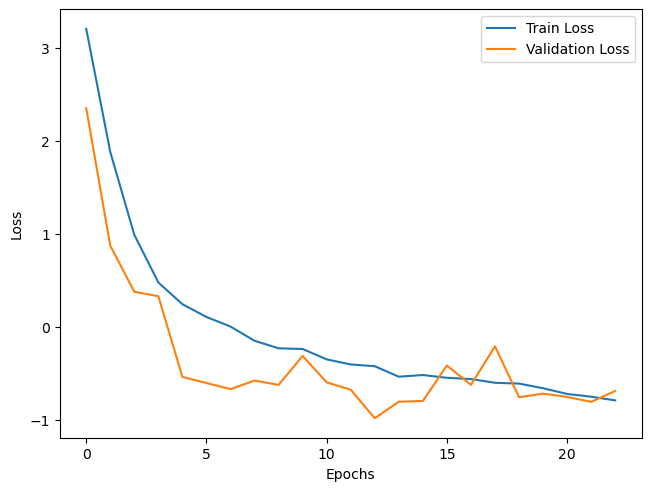

In [ ]:
# Plot training/validation loss
dl.plot_losses(train_losses, val_losses, PATH=LOSS_PATH)

### Evaluating the model

In [24]:
# Compute the test predictions and loss
y_test_pred, test_loss = dl.test_nn(test_loader, model, loss_fn, device)
y_test_pred = y_test_pred.reshape(-1, 2, n_labels)

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Train Loss: -0.7881
Final Validation Loss: -0.6884
Final Test Loss: -1.0881


In [25]:
# Descale the predictions
labels_test_pred = scaler.inverse_transform(y_test_pred[:, 0, :])
uncertainties_test = scaler.scale_ * y_test_pred[:, 1, :]

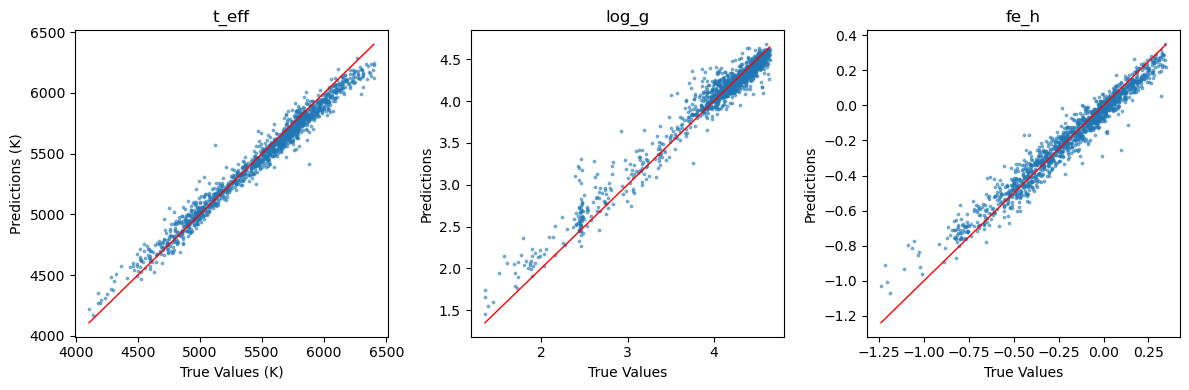

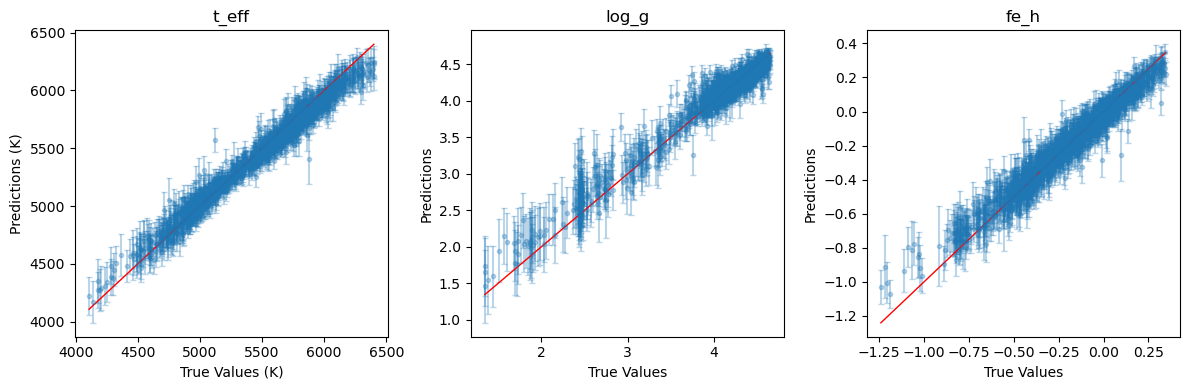

In [ ]:
# Plot predicted values vs true values
galah.plot_predicted_vs_true(labels_test, labels_test_pred, n_labels=n_labels, label_names=label_names, units=units,
                                PATH=PREDVSTRUE_PATH)
galah.plot_predicted_vs_true(labels_test, labels_test_pred, n_labels=n_labels, label_names=label_names, units=units, 
                             errors=uncertainties_test, PATH=PREDVSTRUE_ERR_PATH)

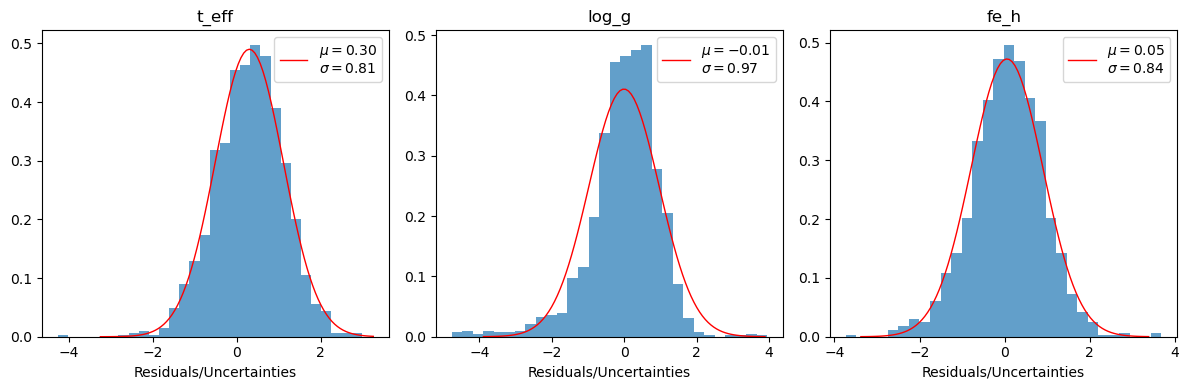

In [27]:
# Plot the pull distribution
galah.plot_pull_distribution(labels_test, labels_test_pred, n_labels=n_labels, label_names=label_names, errors=uncertainties_test,
                                 PATH=PULL_PATH)

In [33]:
# Compute the quantiles of the model
quantiles = galah.get_quantiles(test_loader, model, device=device)

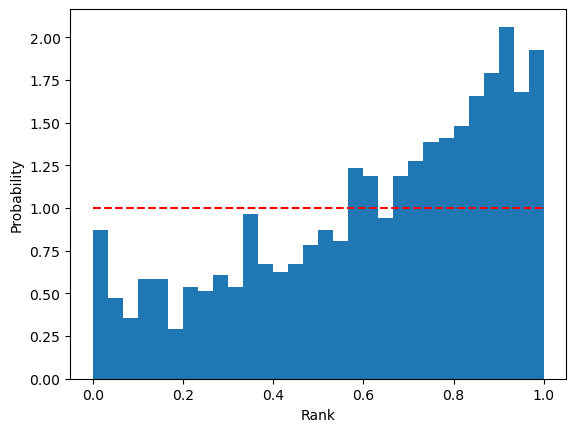

In [37]:
# Plot the coverage test
galah.plot_coverage_test(quantiles, PATH=COV_PATH)

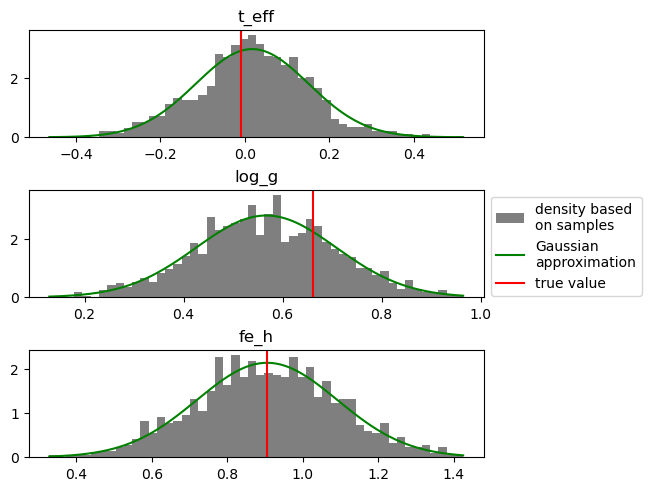

In [38]:
# Plot the pdf for an example sample
with torch.no_grad():
    batch_x, batch_y = next(iter(test_loader))
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    model.visualize_pdf(batch_x, truth=batch_y[0], label_names=label_names, PATH=PDF_PATH)